In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

In [2]:
sx = qt.sigmax()
sz = qt.sigmaz()

ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

# 1-Qubit case

In [162]:
class LSZ_experiment():

    def __init__(self, alpha, epsilon, total_time, wait_time, max_s):
        '''
        Params:
        epsilon: Coefficient of X Hamiltonian
        alpha: Coefficient of target Hamiltonian
        total_time: Total time of the algorithm
        wait_time: Waiting time in the middle of the LSZ algorithm (0 if just doing LZ)
        max_s: maximum of s parameter. Will control slope of schedule
        '''

        self.e = epsilon
        self.a = alpha

        self.to =  0
        self.tf = total_time
        self.tw = wait_time

        assert wait_time < total_time, f"Wait time ({wait_time}) has to be lower than total time ({total_time})"

        self.tr = (self.tf - self.tw)/2

        self.s_max = max_s
        self.slope = self.s_max/self.tr

        self.npsx = np.array([[0, 1], [1, 0]])
        self.npsz = np.array([[1, 0], [0, -1]])

        self.qtsx = qt.sigmax()
        self.qtsz = qt.sigmaz()

    
    def trapezoid_s(self, t):
        return np.minimum(self.s_max, self.slope * np.minimum(t, self.tf - t))

    def H_numpy(self, t):
        #Choose mode
        # s = self.trapezoid_s(t)
        s = self.s_max - self.trapezoid_s(t)
        return self.e*self.npsx + self.a*s*self.npsz
    
    def show_schedule(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)
        s_list = np.zeros(len(t_list))

        for i,t in enumerate(t_list):
            s_list[i] = self.trapezoid_s(t)
        
        return t_list, s_list
    
    def show_spectrum(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)
        eg_val_list = []
        eg_vec_list = []

       #Diagonalize for each time step 
        for i,t in enumerate(t_list):
            H = self.H_numpy(t)
            egvals, egvecs = np.linalg.eigh(H)

            eg_val_list.append(egvals)
            eg_vec_list.append(egvecs)

        return t_list, eg_val_list, eg_vec_list

                    




In [ ]:
#These two control the relative size of the minimum and maximum gaps
alpha = 1
epsilon = 1

#Wait time will also control speed of the ramp
total_time = 1
wait_time = 0.5

#This also controls relative size of min gap. We can control it with either parameter
max_s = 1

n_steps = 101

test_lsz = LSZ_experiment(alpha, epsilon, total_time, wait_time, max_s)

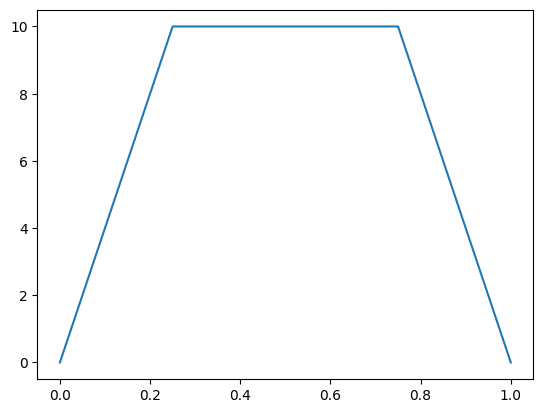

In [196]:
t_list, s_list = test_lsz.show_schedule(n_steps)

plt.plot(t_list, s_list)

In [197]:
t_list, egvals, egvecs = test_lsz.show_spectrum(n_steps)

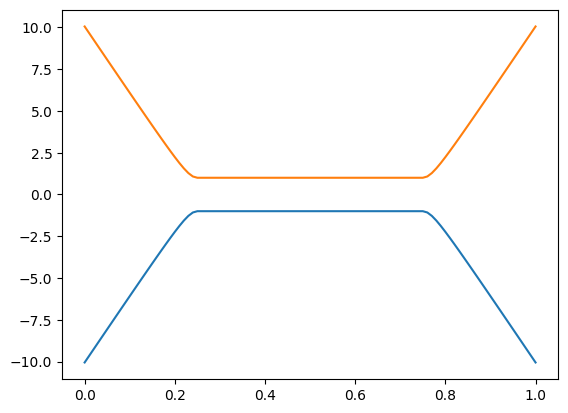

In [198]:
plt.plot(t_list, egvals)